In [1]:
# Medical Insurance Cost Prediction using Support Vector Regression (SVR)

#Author: Manikandaprabhu.S  
#Objective: Predict Medical Insurance Cost using Support Vector Regression (SVR)

In [2]:
## 1. Importing Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
## 2. Loading the Dataset
dataset = pd.read_csv("insurance_pre.csv")
pd.options.display.max_rows = 10
dataset

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


In [4]:
## 3. Data Preprocessing (Handling Categorical Variables)
data = pd.get_dummies(dataset,dtype=int)
data

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes
0,19,27.900,0,16884.92400,1,0,0,1
1,18,33.770,1,1725.55230,0,1,1,0
2,28,33.000,3,4449.46200,0,1,1,0
3,33,22.705,0,21984.47061,0,1,1,0
4,32,28.880,0,3866.85520,0,1,1,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,0,1,1,0
1334,18,31.920,0,2205.98080,1,0,1,0
1335,18,36.850,0,1629.83350,1,0,1,0
1336,21,25.800,0,2007.94500,1,0,1,0


In [5]:
## 4. Exploratory Data Inspection
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1338 non-null   int64  
 1   bmi         1338 non-null   float64
 2   children    1338 non-null   int64  
 3   charges     1338 non-null   float64
 4   sex_female  1338 non-null   int64  
 5   sex_male    1338 non-null   int64  
 6   smoker_no   1338 non-null   int64  
 7   smoker_yes  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [6]:
data.columns

Index(['age', 'bmi', 'children', 'charges', 'sex_female', 'sex_male',
       'smoker_no', 'smoker_yes'],
      dtype='object')

In [7]:
## 5. Preparing Features and Target Variable
Features = data[['age', 'bmi', 'children','sex_male','smoker_yes']]
Target = data[['charges']].values.ravel()
Features

,age,bmi,children,sex_male,smoker_yes
0,19,27.900,0,0,1
1,18,33.770,1,1,0
2,28,33.000,3,1,0
3,33,22.705,0,1,0
4,32,28.880,0,1,0
...,...,...,...,...,...
1333,50,30.970,3,1,0
1334,18,31.920,0,0,0
1335,18,36.850,0,0,0
1336,21,25.800,0,0,0


In [8]:
## 6. Splitting Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(Features,Target,test_size=1/3,random_state=0)
x_train

,age,bmi,children,sex_male,smoker_yes
482,18,31.35,0,0,0
338,50,32.30,1,1,1
356,46,43.89,3,1,0
869,25,24.30,3,0,0
182,22,19.95,3,1,0
...,...,...,...,...,...
763,27,26.03,0,1,0
835,42,35.97,2,1,0
1216,40,25.08,0,1,0
559,19,35.53,0,1,0


In [9]:
## 7. Feature Scaling (Important for SVR)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
x_test


array([[ 0.89108031, -0.07576237, -0.0755796 ,  1.01127431, -0.49929923],
       [ 0.5336223 , -0.21009861, -0.0755796 , -0.98885138, -0.49929923],
       [ 0.6051139 ,  1.60182214,  0.75672907,  1.01127431,  2.00280702],
       ...,
       [-1.46814257,  0.65256665,  0.75672907, -0.98885138,  2.00280702],
       [-0.82471815,  0.37742013,  1.58903774,  1.01127431, -0.49929923],
       [ 0.89108031,  1.24817794,  0.75672907, -0.98885138, -0.49929923]],
      shape=(446, 5))

In [10]:
## 8. Training SVR Model with Hyperparameter Tuning (GridSearchCV)
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
param_grid = {'kernel':['rbf','poly','sigmoid','linear'],'C':[10,100,1000,2000,3000],'gamma':['auto','scale']}

grid=GridSearchCV(SVR(), param_grid, refit=True, verbose=3, n_jobs=-1)

grid.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,SVR()
,param_grid,"{'C': [10, 100, ...], 'gamma': ['auto', 'scale'], 'kernel': ['rbf', 'poly', ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,kernel,'poly'


In [11]:
## 9. Hyperparameter Results Analysis

re=grid.cv_results_
print("The R_score value for best parameter {}:".format(grid.best_params_))

The R_score value for best parameter {'C': 3000, 'gamma': 'scale', 'kernel': 'poly'}:


In [12]:
table=pd.DataFrame.from_dict(re)
table

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.062545,0.004363,0.026769,0.005109,10,auto,rbf,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",-0.004176,0.022594,-0.118956,-0.082926,-0.103473,-0.057387,0.056205,35
1,0.046425,0.003155,0.011090,0.003182,10,auto,poly,"{'C': 10, 'gamma': 'auto', 'kernel': 'poly'}",0.047420,0.077536,-0.060527,-0.009476,-0.050823,0.000826,0.054025,32
2,0.071249,0.007126,0.014226,0.001402,10,auto,sigmoid,"{'C': 10, 'gamma': 'auto', 'kernel': 'sigmoid'}",0.044787,0.081689,-0.072355,-0.027541,-0.051470,-0.004978,0.058648,34
3,0.047936,0.004899,0.008872,0.001007,10,auto,linear,"{'C': 10, 'gamma': 'auto', 'kernel': 'linear'}",0.387624,0.461268,0.288301,0.340540,0.297825,0.355112,0.063693,25
4,0.071996,0.006109,0.028959,0.001424,10,scale,rbf,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",-0.003956,0.022453,-0.119035,-0.082925,-0.103510,-0.057395,0.056230,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35,0.114772,0.017877,0.007484,0.001238,3000,auto,linear,"{'C': 3000, 'gamma': 'auto', 'kernel': 'linear'}",0.669819,0.588893,0.587076,0.572849,0.557014,0.595130,0.039068,17
36,0.112087,0.018414,0.030511,0.001788,3000,scale,rbf,"{'C': 3000, 'gamma': 'scale', 'kernel': 'rbf'}",0.795353,0.772801,0.846034,0.811601,0.725615,0.790281,0.040189,6
37,0.168112,0.063242,0.006302,0.002411,3000,scale,poly,"{'C': 3000, 'gamma': 'scale', 'kernel': 'poly'}",0.805169,0.783163,0.852345,0.810160,0.748201,0.799808,0.034165,1
38,0.083235,0.012388,0.017062,0.004797,3000,scale,sigmoid,"{'C': 3000, 'gamma': 'scale', 'kernel': 'sigmo...",-1.651895,-2.010670,-1.468842,-1.712109,-0.961821,-1.561068,0.346643,40


In [13]:
## 10. Model Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

y_pred = grid.predict(x_test) 

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
mae = mean_absolute_error(y_test, y_pred)
n = x_test.shape[0]  
p = x_test.shape[1]   
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("Mean Absolute Error:", mae)
print("Adjusted R2 Score:", adjusted_r2)

R2 Score: 0.8577898390283539
Mean Squared Error: 22801294.69615476
Root Mean Squared Error: 4775.070124736888
Mean Absolute Error: 2198.2354059174336
Adjusted R2 Score: 0.8561738144718579


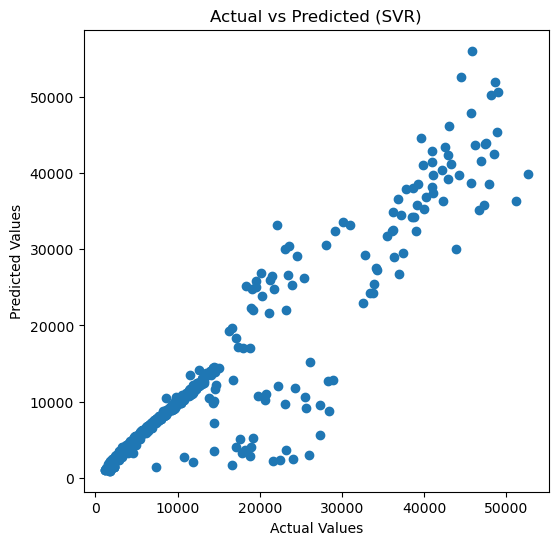

In [14]:
## 11. Visualizing Model Performance (Actual vs Predicted)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (SVR)")
plt.show()

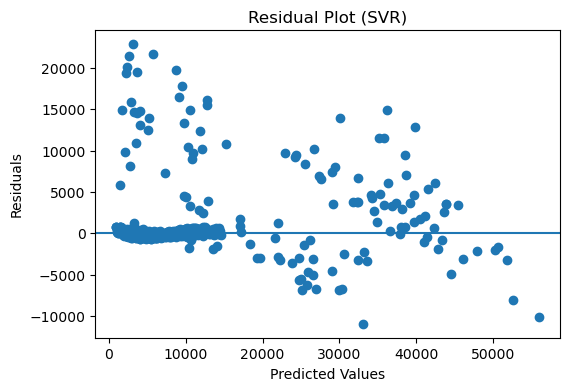

In [15]:
## 11.1. Visualizing Model Performance (Residual Plot (Shows errors))

residuals = y_test - y_pred

plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (SVR)")
plt.show()

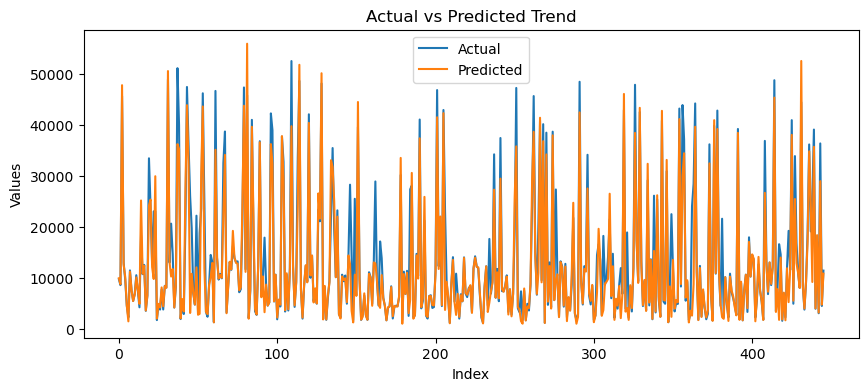

In [16]:
## 11.2. Visualizing Model Performance (Line Plot(Actual vs Predicted))

plt.figure(figsize=(10,4))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Trend")
plt.xlabel("Index")
plt.ylabel("Values")
plt.show()

In [17]:
## 12. Saving the Trained Model and Scaler
best_model = grid.best_estimator_

import pickle

# Save scaler
pickle.dump(sc, open("scaler.pkl", "wb"))

# Save model
pickle.dump(best_model, open("Finalized_svr_model.sav", "wb"))

In [19]:
## Conclusion:

# The Support Vector Regression (SVR) model was successfully implemented to predict medical insurance costs based on factors such as age, BMI, number of children, gender, and smoking status.
# Feature scaling significantly improved the performance of the SVR model, as it is sensitive to the scale of input data. Hyperparameter tuning using GridSearchCV helped identify the optimal combination of kernel, C, and gamma, leading to improved prediction accuracy.
# The model achieved a good balance between bias and variance, as reflected in the evaluation metrics (R², MSE, RMSE). Visualization of predictions and residuals confirms that the model captures the overall trend of the data effectively.
# This project demonstrates the importance of preprocessing, scaling, and tuning in building efficient machine learning models for real-world regression problems.